# 04 — Analysis
## Evaluation + Recommendations + Visualization

Full evaluation of clustering results, recommendations for fixing anti-patterns,
and final visualizations.

Modules used: `evaluator.py`, `recommender.py`

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from evaluator import Evaluator
from recommender import Recommender

with open(Path.cwd().parent / "output" / "intermediate_03.pkl", "rb") as f:
    data = pickle.load(f)

labels = data["labels"]
gt_labels = data["gt_labels"]
table_names = data["table_names"]
X_reduced = data["X_reduced"]
X_2d = data["X_2d"]
schema = data["schema"]
all_columns = data["all_columns"]
sil_values = data["sil_values"]
sil_avg = data["sil_avg"]
ari = data["ari"]
nmi = data["nmi"]
column_index = data["column_index"]

print(f"Loaded: {len(labels)} columns, {len(set(labels))} clusters, ARI={ari:.4f}")

Loaded: 235 columns, 5 clusters, ARI=-0.0065


## 1. Internal Evaluation

In [2]:
evaluator = Evaluator()
metrics = evaluator.evaluate(X_reduced, labels)

print("Internal Metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Internal Metrics:
  silhouette: 0.1691
  davies_bouldin: 1.6343
  calinski_harabasz: 41.5560
  n_clusters: 5
  n_samples: 235
  n_noise: 0


In [3]:
column_table_map = [t.name for t in schema.tables for c in t.columns]
cross_table = evaluator.cross_table_analysis(column_table_map, labels)

print(f"Average table purity: {cross_table['average_purity']:.2%}")
for table, info in sorted(cross_table["table_purity"].items()):
    print(f"  {table:30s} purity={info['purity']:.0%}  ({info['total_columns']} cols, cluster #{info['majority_cluster']})")

Average table purity: 40.48%
  AUDITORIA_LOG                  purity=43%  (7 cols, cluster #1)
  BACKUP_DATOS                   purity=26%  (50 cols, cluster #0)
  CACHE_TEMPORAL                 purity=25%  (4 cols, cluster #2)
  CATEGORIAS                     purity=33%  (6 cols, cluster #0)
  CLIENTES_DIRECCIONES           purity=40%  (10 cols, cluster #1)
  CONFIGURACION                  purity=50%  (6 cols, cluster #1)
  DEPARTAMENTOS                  purity=67%  (3 cols, cluster #1)
  EMPLEADOS                      purity=30%  (10 cols, cluster #3)
  EMPLEADOS_HISTORIAL            purity=29%  (7 cols, cluster #4)
  INVENTARIO                     purity=50%  (6 cols, cluster #4)
  METADATA                       purity=67%  (6 cols, cluster #1)
  ORDENES_COMPRA                 purity=36%  (11 cols, cluster #4)
  PRODUCTOS                      purity=56%  (9 cols, cluster #2)
  PROVEEDORES                    purity=50%  (4 cols, cluster #4)
  REPORTES                       purity=33%

In [4]:
validation = evaluator.validate_against_ground_truth(labels, gt_labels, X_reduced)
print(evaluator.print_validation_report(validation))

--------------------------------------------------
VALIDACION H1 — Ground Truth
--------------------------------------------------
  Adjusted Rand Index (ARI):  -0.0065
  Normalized Mutual Info:    0.0352
  Columnas con GT:           235
  Anomaly (noise) detection:
    Precision: 0.00%
    Recall:    0.00%
    F1:        0.00%
    Support:   0
  Structural anomalies (centroid distance):
    Count:  12
    Ratio:  5.11%
    Mean distance: 0.8717
    Std distance:  0.1937
--------------------------------------------------


## 2. Structural Anomaly Detection

In [5]:
anomaly = evaluator.centroid_anomaly_scores(X_reduced, labels, percentile=95)

print(f"Structural anomalies: {anomaly['n_anomalies']} / {X_reduced.shape[0]}")
print(f"Mean distance: {anomaly['mean_distance']:.4f}, Threshold (p95): {anomaly['threshold']:.4f}")

if anomaly['n_anomalies'] > 0:
    print("Anomalous columns:")
    for idx in anomaly['anomaly_indices']:
        print(f"  {column_index[idx]} (cluster {labels[idx]})")

Structural anomalies: 12 / 235
Mean distance: 0.8717, Threshold (p95): 1.1675
Anomalous columns:
  BACKUP_DATOS.COL_023 (cluster 0)
  CATEGORIAS.ACTIVO (cluster 0)
  PRODUCTOS.PROVEEDORES_ID (cluster 1)
  PRODUCTOS.UBICACION_ALMACEN (cluster 2)
  TABLA_BASE_DATOS.E (cluster 1)
  TABLA_BASE_DATOS.K (cluster 4)
  TABLA_BASE_DATOS.L (cluster 2)
  TABLA_BASE_DATOS.N (cluster 0)
  TABLA_BASE_DATOS.AAF (cluster 4)
  TODO_EN_UNO.OBSERVACIONES (cluster 2)
  TODO_EN_UNO.BACKUP_COLUMN (cluster 1)
  VENTAS.PRODUCTO_FK (cluster 2)


## 3. Recommendations

In [6]:
recommender = Recommender()
recommendations = recommender.recommend(schema, labels, column_table_map)
print(recommender.print_recommendations(recommendations))

RECOMMENDATIONS PER CLUSTER

Cluster #0 [ALTA] (44 columns, 18 tables)
  Dominant type: VARCHAR2
  Tables: AUDITORIA_LOG, BACKUP_DATOS, CACHE_TEMPORAL, CATEGORIAS, CLIENTES_DIRECCIONES
    ... and 13 more
  - Mayoria de columnas permite nulos (100%)
  - 'FECHA_NACIMIENTO' parece fecha pero es VARCHAR2
  - 'FECHA_ALTA' parece fecha pero es VARCHAR2
  - 'FECHA_ACTUALIZACION' parece fecha pero es VARCHAR2
  - 'FECHA_ORDEN' parece fecha pero es VARCHAR2
  - 'FECHA_O_DIRECCION' parece fecha pero es VARCHAR2
  - 'FECHA' parece fecha pero es VARCHAR2
  - 'SALARIO_NUEVO' parece numero pero es VARCHAR2
  - 'PRECIO' parece numero pero es VARCHAR2
  - 'ACTIVO' parece booleano pero es CHAR
    -> Evaluar si los nulos son semanticamente validos o indican datos faltantes
    -> Fecha como texto: migrar a DATE
    -> Fecha como texto: migrar a DATE
    -> Fecha como texto: migrar a DATE
    -> Fecha como texto: migrar a DATE
    -> Fecha como texto: migrar a DATE
    -> Fecha como texto: migrar a DAT

## 4. Final Visualizations

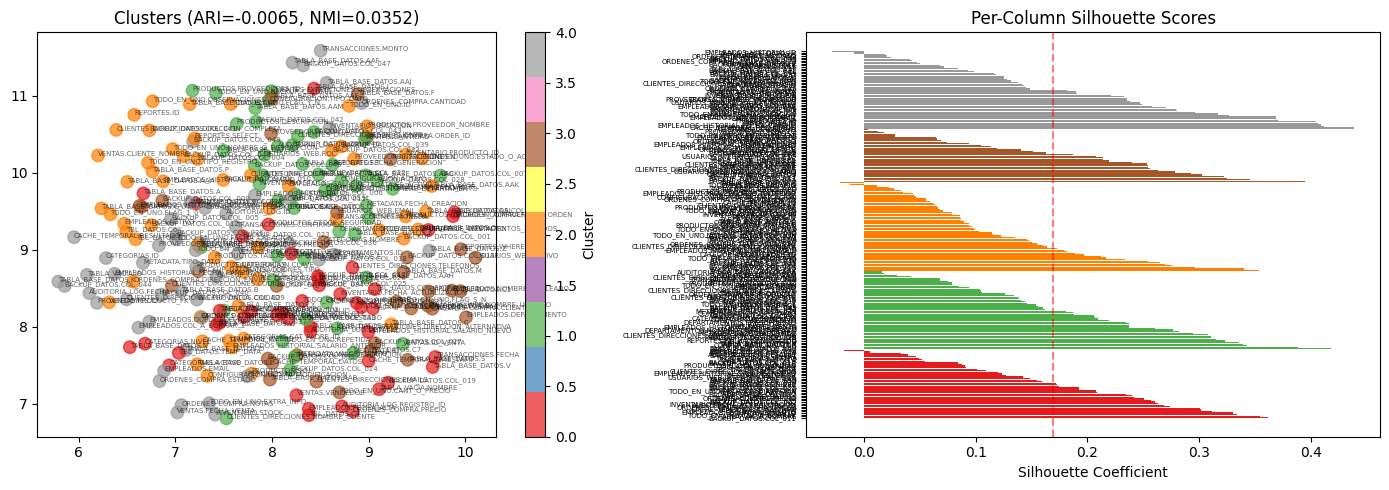

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="Set1", alpha=0.7, s=80)
for i, name in enumerate(column_index):
    axes[0].annotate(name, (X_2d[i, 0], X_2d[i, 1]), fontsize=5, alpha=0.6)
axes[0].set_title(f"Clusters (ARI={ari:.4f}, NMI={nmi:.4f})")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

df_sil = pd.DataFrame({"column": column_index, "table": column_table_map, "silhouette": sil_values, "cluster": labels})
df_sil = df_sil.sort_values(["cluster", "silhouette"], ascending=[True, False])
colors = plt.cm.Set1(np.linspace(0, 1, len(df_sil["cluster"].unique())))
color_map = {c: colors[i] for i, c in enumerate(sorted(df_sil["cluster"].unique()))}
bar_colors = [color_map[c] for c in df_sil["cluster"]]
axes[1].barh(range(len(df_sil)), df_sil["silhouette"], color=bar_colors)
axes[1].set_yticks(range(len(df_sil)))
axes[1].set_yticklabels(df_sil["column"], fontsize=5)
axes[1].set_xlabel("Silhouette Coefficient")
axes[1].set_title("Per-Column Silhouette Scores")
axes[1].axvline(x=sil_avg, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

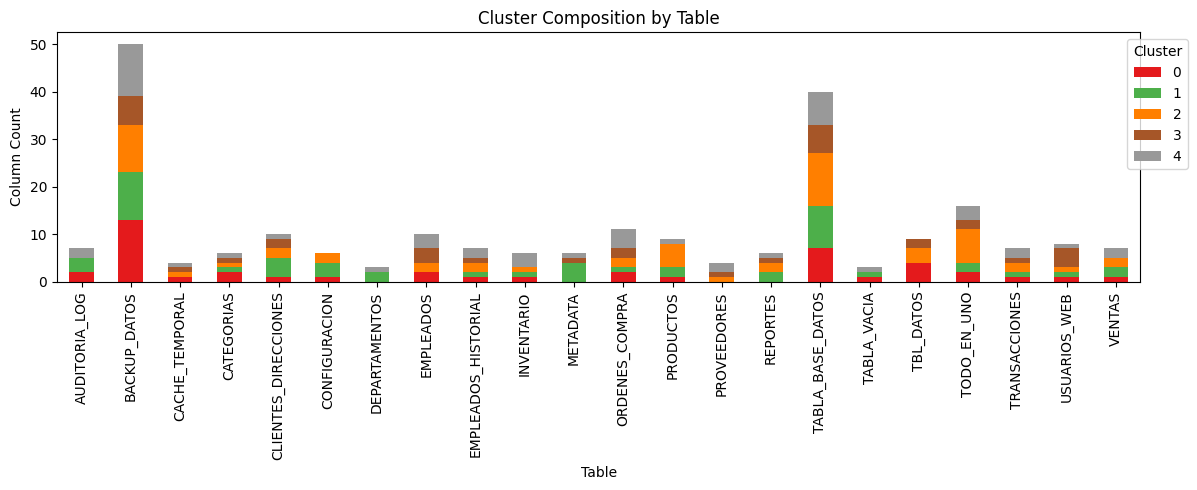

In [8]:
ct = pd.crosstab(pd.Series(column_table_map, name="Table"), pd.Series(labels, name="Cluster"))
ct.plot(kind="bar", stacked=True, colormap="Set1", figsize=(12, 5))
plt.title("Cluster Composition by Table")
plt.xlabel("Table")
plt.ylabel("Column Count")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 5. Generate Reports

In [9]:
output_dir = Path.cwd().parent / "output" / "notebook_results"
output_dir.mkdir(exist_ok=True)

report = "\n".join([
    "=" * 60, "EVALUATION REPORT", "=" * 60, "",
    f"Tables: {len(table_names)}", f"Columns: {len(labels)}", f"Clusters: {len(set(labels))}", "",
    "--- Internal Metrics ---",
    f"  Silhouette:        {metrics['silhouette']:.4f}",
    f"  Davies-Bouldin:    {metrics['davies_bouldin']:.4f}",
    f"  Calinski-Harabasz: {metrics['calinski_harabasz']:.2f}", "",
    "--- External Validation ---",
    f"  ARI: {ari:.4f}", f"  NMI: {nmi:.4f}", "",
    "--- Table Purity ---",
    f"  Average: {cross_table['average_purity']:.2%}", "",
    "--- Anomalies ---",
    f"  Count: {anomaly['n_anomalies']} / {X_reduced.shape[0]}",
])

with open(output_dir / "evaluation_report.txt", "w") as f:
    f.write(report)

rec_text = "\n".join([
    "=" * 60, "RECOMMENDATIONS", "=" * 60, "",
    *[
        f"Cluster #{r['cluster_id']} [{r['severity'].upper()}] ({r['total_columns']} cols)\n"
        f"  Tables: {', '.join(r['tables_involved'][:5])}\n"
        + "\n".join(f"  - {i}" for i in r["issues"]) + "\n"
        + "\n".join(f"    -> {fx}" for fx in r["recommendations"])
        for r in recommendations
    ],
])

with open(output_dir / "recommendations.txt", "w") as f:
    f.write(rec_text)

print(f"Reports saved to {output_dir}")

Reports saved to /Users/jesusmarentes/Documents/Documents - MacBook Air de Jesús/db_bad_clust/output/notebook_results
